<a href="https://colab.research.google.com/github/slowlyP/AI_26/blob/main/05_03_%ED%8A%B8%EB%A6%AC%EC%9D%98%EC%95%99%EC%83%81%EB%B8%94.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 지금까지 k-최근접이웃알고리즘, 선형회귀, 릿지, 라쏘, 다항회귀, 로지스틱회귀
# 등을 배웠고 확률적경사하강법을 이용한 분류과 결정트리 모델까지 학습을 함

# 테스트 세트말고 검증세트를 사용하는 cv(교차검증), 하이퍼파라미터튜닝등을 사용

# 코렙에는 왠만한 AI용 라이브러리가 설치 되어 있는데 안되어 있는 것은 수동 설치!!!
!pip install xgboost
!pip install pycaret

In [ ]:
# 앙상블 : 단어 그대로 여러 단순한 모델을 결합하여 정확한 모델을 만드는 방법
# 정형데이터 : 지금까지 학습한 수치 자료가 있는 값
# 비정형데이터 : 데이터베이스나 엑셀로 표현하기 어려운 데이터
# (텍스트 데이터,디카사진,mp3등) -> 신경망 알고리즘

# 랜덤 포레스트 : 결정 트리를 랜덤하게 만들어 결정트리(나무) 숲 을만듬
#       -> 최종 예측

# 1000개의 샘플이 들어 있는 가방에서 100개를 생픔을 뽑을때 1개를 뽁고
# 뽑았던 1개를 다시 가방에 넣음
# 중복된 샘플을 뽑을수 있음 -> 부트스트랩 샘플이라고함
# 부트스트랩 : 데이터 세트에서 중복을 허용하여 데이터를 샘플링


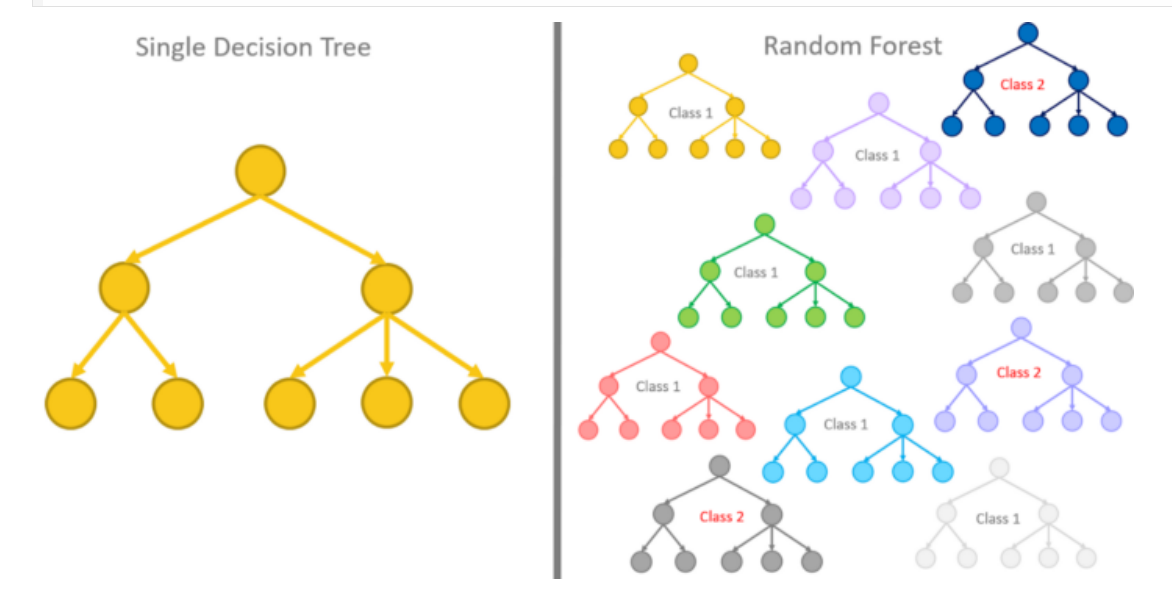

In [ ]:
# 분류 모델인 : RandomForestClassifier은
# 기본적으로 전체 특성 개수의 제곱근 만큼 특성을 선택한다.
# 즉 4개의 특성이 있다면 노드마다 2개를 랜덤하게 선택하여 사용
# 다만 회귀 모델인 RandomForestRegressor 은 전체 특성을 사용
# 사이킷 런의 랜덤 포레스트는 기본적으로 100개의 결정 트리를 이런 방식으로 훈련한다.

# 그다음 분류일 때는 각 트리의 클래스별 확률을 평균하여
# 가장 높은 확률을 가진 클래스를 예측으로 삼는다.
# 회귀일 때는 단순히 각 트리의 예측을 평균함

# 분류  : 샘플을 몇개의 클래스 중 하나로 분류하는 문제
# 회귀  : 임의의 어떤 숫자를 예측하는 문제

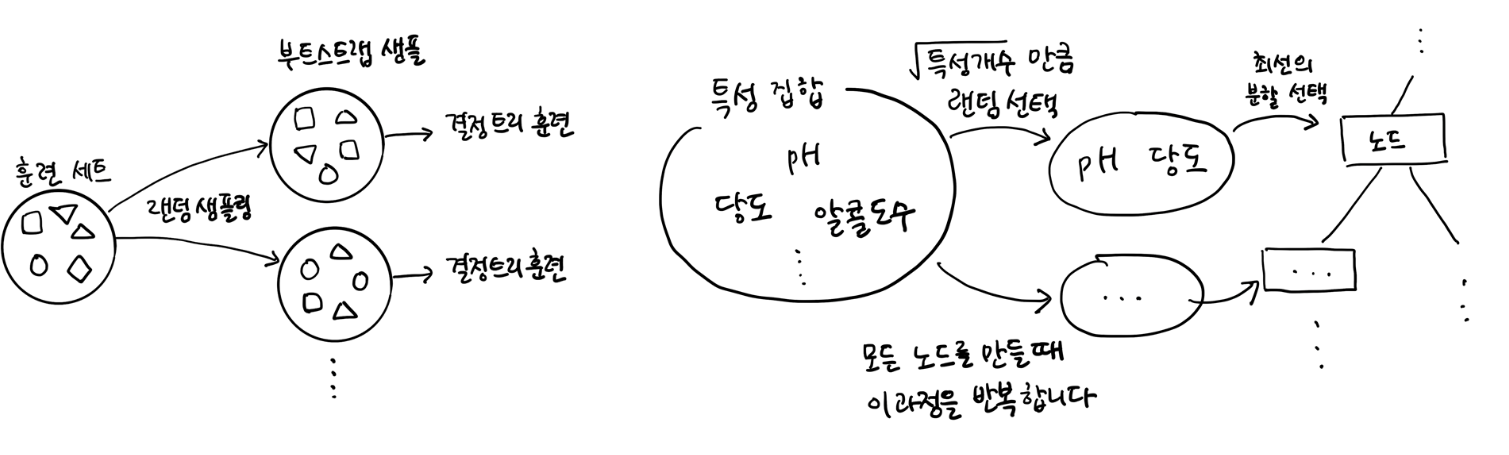

In [2]:
# 와인찾기 데이터
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

wine = pd.read_csv('https://bit.ly/wine_csv_data')

data = wine[['alcohol' , 'sugar', 'pH']].to_numpy()
target = wine['class'].to_numpy()
data

array([[ 9.4 ,  1.9 ,  3.51],
       [ 9.8 ,  2.6 ,  3.2 ],
       [ 9.8 ,  2.3 ,  3.26],
       ...,
       [ 9.4 ,  1.2 ,  2.99],
       [12.8 ,  1.1 ,  3.34],
       [11.8 ,  0.8 ,  3.26]])

In [3]:
target

array([0., 0., 0., ..., 1., 1., 1.])

In [4]:
# 훈련세트 80%와 테스트 세트 20% 로 나눔
train_input, test_input, train_target, test_target = train_test_split(
    data, target,test_size=0.2, random_state=42)
print(train_input.shape, test_input.shape)
# 여기서 만든 테스트 20%는 검증이 끝난 마지막 단계에서 평가용으로 사용

(5197, 3) (1300, 3)


In [5]:
from sklearn.model_selection import cross_validate #크로스 검증용
from sklearn.ensemble import RandomForestClassifier # 100개의 결정 트리를 사용

rf = RandomForestClassifier(n_jobs=-1, random_state=42) # n_jobs=-1 모든 cpu 사용
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1)
# return_train_score=True 검증 점수와 훈련세트에 대한 점수도 리턴

print(np.mean(scores['train_score']), np.mean(scores['test_score']))


0.9973541965122431 0.8905151032797809


In [7]:
# 랜덤 포레스트는 결정트리의 앙상블이기 떄문에 결정트리가 제공하는 중요한 매개변수를 모두 제공함
# 결정 트리의 큰 장점중 하나인 특성 중요를 계산한다.
# 랜덤 포레스트의 특성 중요도는 각 결정 트리의 특성 중요도를 취합 한 것이다.
# 훈련 후에 중요도를 출력 해보자.
rf.fit(train_input, train_target) # 훈련 후 특성 중요도 출력
print(rf.feature_importances_)


[0.23167441 0.50039841 0.26792718]


In [8]:
# [0.23167441 0.50039841 0.26792718] 랜덤포레스트 현재 결과
# [0.12345626 0.86862934 0.0079144 ] LogisticRegression 이전 결과

# 알콜도수 , 당도 , pH 비교 해보자.
# 당도의 중요도가 감소하고, 알콜 도수와 pH 중요도가 상승함
# 이유는 랜덤포레스트가 특성 일부를 랜덤하게 선택하여 결정 트리를 훈련함(중복허용)
# 하나의 특성에 과도하게 집중하지 않고 좀 더 많은 특성이 훈련에 기여할 기회가 됨(과대적합을 줄임)


In [9]:
# RandomForestClassifier 기능중에 자체적으로 모델을 평가하는 점수를 얻을 수 있다.
# OOB(out of bag) 부트 스트랩에 포함되지 않고 남은 샘플 -> 결정 트리 평가용(검증 세트로 활용)
# oob_score=True -> 랜덤 포레스트는 각 결정 트리의 oob 점수를 평균하여 출력(oob_score_)
rf = RandomForestClassifier(oob_score=True, n_jobs=-1, random_state=42)

rf.fit(train_input, train_target)
print(rf.oob_score_) # 교차 검증 점수와 비슷한 결과를 얻음
# oob 점수를 사용하면 교차 검증을 대신할 수 있어 결과적으로 훈련 세트에 더 많은 샘플을 사용할수 있음
# RandomForestClassifier 끝

0.8934000384837406


In [10]:
# 엑스트라 트리 : 100개의 결정 트리 훈련 -> 부트스트랩 샘플을 사용하지 않음( 전체 훈련세트 사용 )
# 대신 노드를 분할할 때 가장 좋은 분할을 찾는 것이 아니라 무작위로 분할함!
# 엑스트라 트리의 결정 트리 splitter='random'
# 하나의 결정 트리에서 특성을 무작위로 분할한다면 선응이 낮아지겠지만
# 많은 트리를 앙상블 하기 때문에 과대 적합을 막고 검증세트의 점수를 높이는 효과가 있다.

from sklearn.ensemble import ExtraTreesClassifier # 엑스트라 트리

et = ExtraTreesClassifier(n_jobs=-1, random_state=42)
scores = cross_validate(et, train_input, train_target, return_train_score=True, n_jobs=-1)

print(np.mean(scores['train_score']), np.mean(scores['test_score']))
# RandomForestClassifier와 결과가 비슷함, 또한 속도가 빠름

0.9974503966084433 0.8887848893166506


In [11]:
et.fit(train_input, train_target)
print(et.feature_importances_)
# [0.20183568 0.52242907 0.27573525] 엑스트라 트리 현재 결과
# [0.23167441 0.50039841 0.26792718] 랜덤포레스트 이전 결과
# [0.12345626 0.86862934 0.0079144 ] LogisticRegression 이전 결과
# 특성 중요도를 보면 결정 트리보다 당도에 대한 의존성이 작다.
##################### 엑스트라 트리 끝 ###########################

[0.20183568 0.52242907 0.27573525]


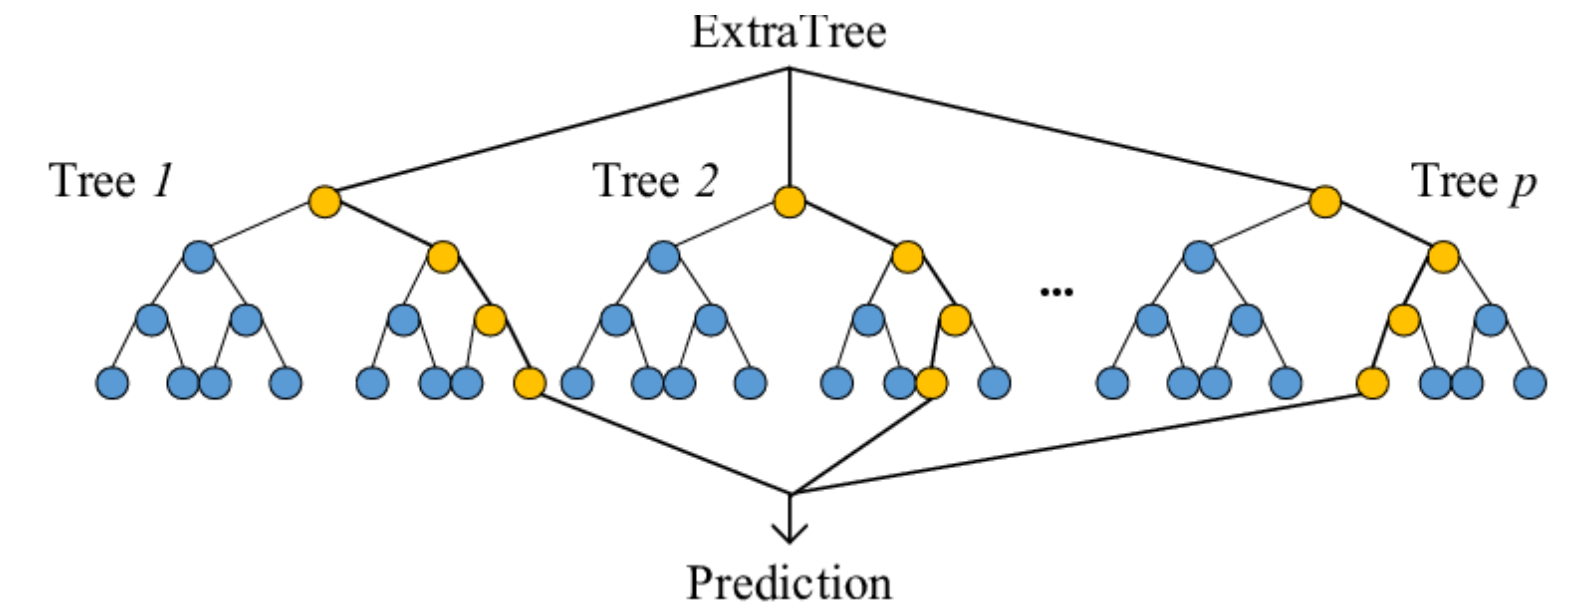

In [12]:
# 그레이디언트 부스팅 Gradient Boosting(기울기)
# 깊이가 얕은 결정 트리를 사용하여 이전 트리의 오차를 보완하는 방식으로 앙상블
# 사이킷 런의 GradienBoostingClassifier은 기본적으로 깊이가 3인 결정 트리를 100개 사용
# 때문에 과대적합에 강하고 일반적인 높은 일반화 성능을 기대함

# Gradient 는 경사 하강법을 사용하여 트리를 앙상블에 추가함.
# 분류 : 로지스틱 손실 함수, 회귀에서는 평균 제곱 오차 함수를 함수를 사용
# 경사 하강법 손실 함수를 산으로 정의하고 가장 낮은 곳으로 찾아 내려오는 과정

# 가장 낮은 곳으로 내려오는 방법은 모델의 가중치와 절편을 조금씩 바꾸는 것
# 결정 트리를 계속 추가하면서 가장 낮은 곳을 찾아 이동, 손실함수의 낮은 곳으로 천천히 이동

from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=42)
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)

print(np.mean(scores['train_score']), np.mean(scores['test_score']))
# 과대 적합 해결

0.8881086892152563 0.8720430147331015


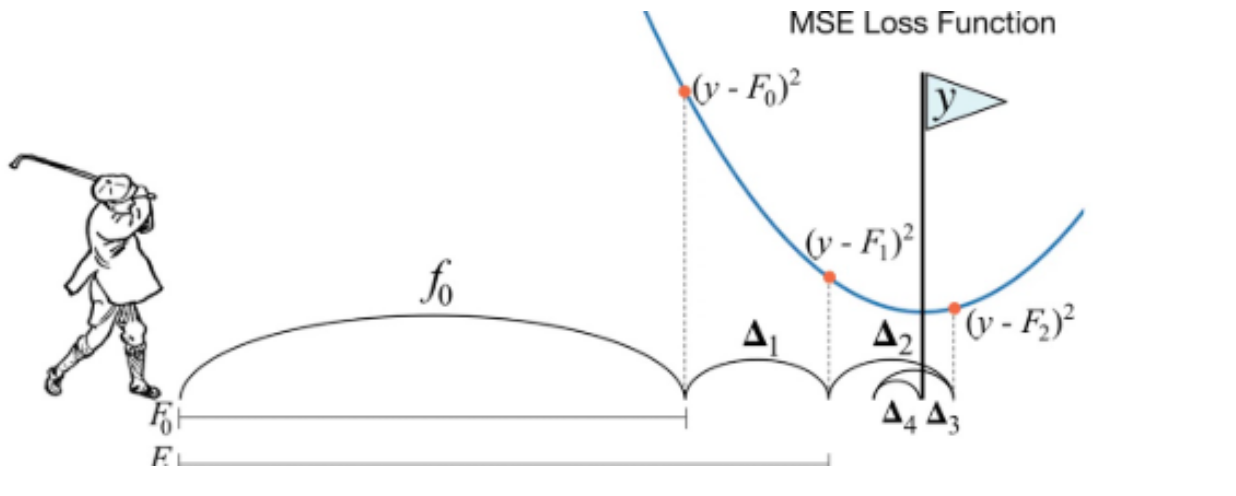

In [15]:
gb = GradientBoostingClassifier(n_estimators=500, learning_rate=0.2, random_state=42)
# n_estimators=500 결정트리개수를 500개로 늘림 기본값 100
# learning_rate=0.2 학습률 기본값 0.1
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)

print(np.mean(scores['train_score']), np.mean(scores['test_score'])) # 교차 검증 점수 확인
# 94.64% 87.80% 훈련과, 검증 점수차이가 10%이상 나지 않으면 괜찮음(과대적합 아님)

0.9464595437171814 0.8780082549788999


In [16]:
gb.fit(train_input, train_target) #훈련시작
print(gb.feature_importances_) #당도에 의존도가 낮음
# 그레이디언트 부스팅이 랜덤 포레스트보다 조금 더 높은 성능이 있다.
# 하지만 순서대로 트리를 추가하기 떄문에 훈련속도가 좀 느리다.
# GradientBoostingClassifier에는 n_jobs=-1 매개값이 없다(구형모델)



[0.15887763 0.6799705  0.16115187]


In [ ]:
# [0.15887763 0.6799705  0.16115187] 그레이디언트 부스팅 현재 결과
# [0.20183568 0.52242907 0.27573525] 엑스트라 트리 이전 결과
# [0.23167441 0.50039841 0.26792718] 랜덤포레스트 이전 결과
# [0.12345626 0.86862934 0.0079144 ] LogisticRegression 이전 결과
#################### 그레이디언트 부스팅 끝 ##########################

In [17]:
# 히스토그램 기반 그레이언트 부스팅 Histogram Gradient : 그레이디언트 부스팅의 개선버전
# 입력 특성을 256 구간으로 나눔 -> 노드를 분할할 때 최적의 분할을 매우 빠르게 찾을 수 있다.
# 특히 256구간 중에서 하나를 떼어 놓고 누락된 값을 위해서 사용함
# HistGradientBoostingClassifier는 기본 매개변수에서 안정적인 성능을 얻을 수있다.
# HistGradientBoostingClassifier에는 트리의 개수를 지정하는데
# n_estimators 대신 max_iter를 사용함(성능 향상용)

# from sklearn.experimental import enable_hist_gradient_boosting 아직 개발중
from sklearn.ensemble import HistGradientBoostingClassifier # 분류용

hgb = HistGradientBoostingClassifier(random_state=42)
scores = cross_validate(hgb, train_input, train_target, return_train_score=True, n_jobs=-1)

print(np.mean(scores['train_score']), np.mean(scores['test_score'])) # 과대 적합 억제 성공!
# 93.21% , 88.01%


0.9321723946453317 0.8801241948619236


In [18]:
from sklearn.inspection import permutation_importance
# permutation_importance 특성 중요도 확인
# : 특성을 하나씩 랜덤하게 섞어서 모델의 성능이 변화되는지 관찰

# 히스토그램기반의 훈련을 진행 -> 훈련세트에서 특성 중요도를 계산해보자.
hgb.fit(train_input, train_target)

#n_repeats=10 랜덤하게 섞을 횟수 (기본 5)
result = permutation_importance(hgb, train_input, train_target, n_repeats=10,
                                random_state=42, n_jobs=-1)
print(result.importances_mean)
# 알콜도수   , 당도    , pH          비교 해보자.
# [0.08876275 0.23438522 0.08027708] 히스토그램 현재결과
# [0.15887763 0.6799705  0.16115187] 그레이디언트 부스팅 이전 결과
# [0.20183568 0.52242907 0.27573525] 엑스트라 트리 이전 결과
# [0.23167441 0.50039841 0.26792718] 랜덤포레스트 이전 결과
# [0.12345626 0.86862934 0.0079144 ] LogisticRegression 이전 결과

[0.08876275 0.23438522 0.08027708]


In [19]:
# 이번에는 테스트 세트에 결과를 확인해 보자
result = permutation_importance(hgb, test_input, test_target, n_repeats=10,
                                random_state=42, n_jobs=-1)
print(result.importances_mean)
# 알콜도수   , 당도    , pH          비교 해보자.
# [0.05969231 0.20238462 0.049     ] 히스토그램 테스트 세트에서 현재 결과
# [0.08876275 0.23438522 0.08027708] 히스토그램 훈련 세트 이전결과
# [0.15887763 0.6799705  0.16115187] 그레이디언트 부스팅 이전 결과
# [0.20183568 0.52242907 0.27573525] 엑스트라 트리 이전 결과
# [0.23167441 0.50039841 0.26792718] 랜덤포레스트 이전 결과
# [0.12345626 0.86862934 0.0079144 ] LogisticRegression 이전 결과

# HistGradientBoostingRegressor 히스토그램 기반 그레이디언트 부스팅의 회귀 버전
###################### 히스토그램 기반 그레이디언트 끝 ########################


[0.05969231 0.20238462 0.049     ]


In [21]:
# 사이킷런 말고도 그레이디언트 부스팅 알고리즘을 구현한 라이브러리가 다수 존재
# XGBoost 대표적임 -> 크로스검증이 가능(cross_validate())
from xgboost import XGBClassifier
# tree_method='hist' 히스토그램 기반 그레이디언트 부스팅용
# 만약 안되면 파이썬에 설치가 안된것임
# !pip install xgboost
# !pip install pycaret -> 세션 다시 시작하고 위에서부터 다시 객체 생성함

xgb = XGBClassifier(tree_method='hist', random_state=42)
scores = cross_validate(xgb, train_input, train_target, return_train_score=True, n_jobs=-1)

print(np.mean(scores['train_score']), np.mean(scores['test_score']))
# 95.58% , 87.82% 와인 교차 검증 점수

0.9567059184812372 0.8783915747390243


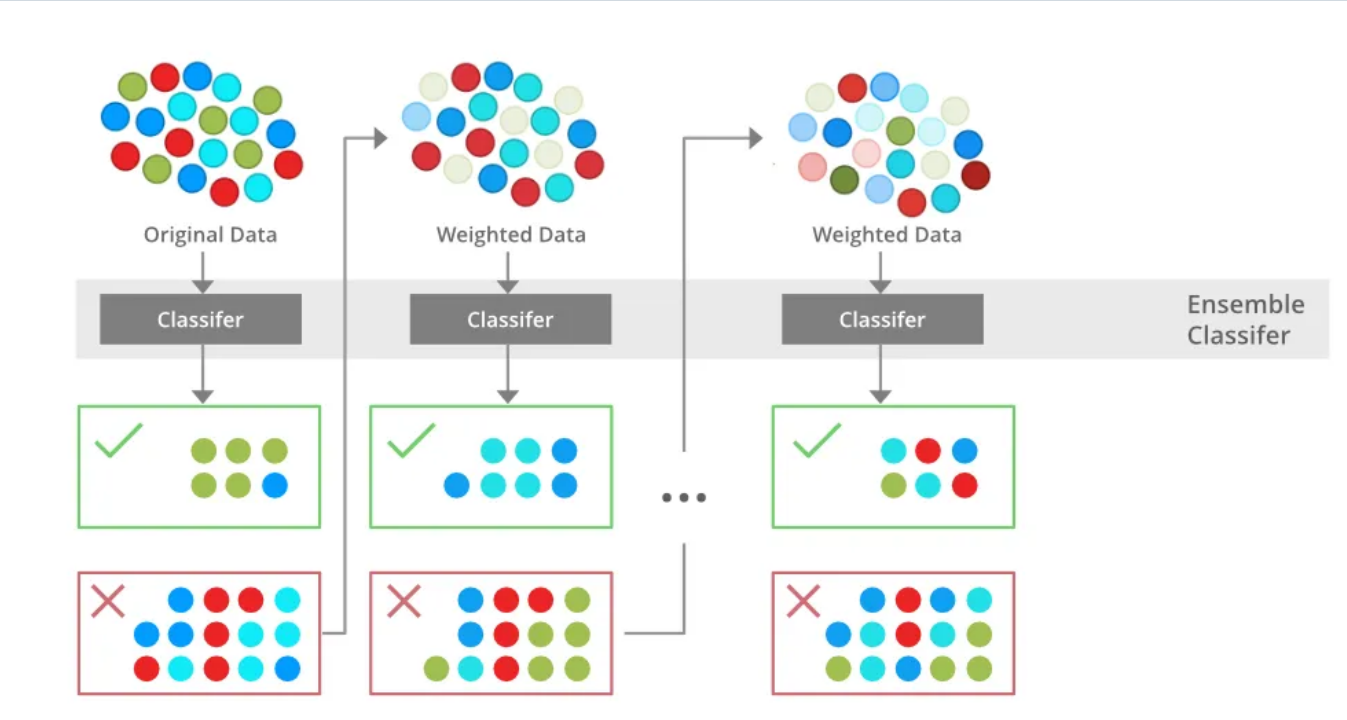

In [22]:
# LGBMClassifier ms 에서 만든 LightGBM^2
from lightgbm import LGBMClassifier

lgb = LGBMClassifier(random_state=42)
scores = cross_validate(lgb, train_input, train_target, return_train_score=True, n_jobs=-1)

print(np.mean(scores['train_score']), np.mean(scores['test_score']))


0.935828414851749 0.8801251203079884


In [ ]:
# 다른 예로 실험
# 빵 가격 분석용 데이터셋 5000개


In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# 1. 가상 데이터 생성 (5,000개)
np.random.seed(42)
n_samples = 5000

data = {
    'flour_price': np.random.normal(150, 20, n_samples),    # 밀가루(원자재)
    'sugar_price': np.random.normal(100, 15, n_samples),    # 설탕(원자재)
    'labor_cost': np.random.uniform(9860, 12000, n_samples),# 인건비(최저임금 반영)
    'energy_cost': np.random.uniform(50, 120, n_samples),   # 전기/가스비
    'delivery_fee': np.random.normal(3000, 500, n_samples), # 물류비
    'shop_rent': np.random.normal(2000, 300, n_samples)     # 임대료
}

df = pd.DataFrame(data)

# 빵 가격 결정 공식 (현실적인 가중치 + 약간의 비선형성 추가)
# 가격 = (밀가루*4) + (설탕*2) + (인건비*0.3) + (에너지*15) + (물류*1.5) + (임대료*0.5) + 오차
df['bread_price'] = (
    df['flour_price'] * 4.2 +
    df['sugar_price'] * 2.1 +
    df['labor_cost'] * 0.35 +
    df['energy_cost'] * 18.0 +  # 최근 에너지값 폭등 반영
    df['delivery_fee'] * 1.2 +
    df['shop_rent'] * 0.4 +
    np.random.normal(0, 50, n_samples)
)

# 데이터 분할
X = df.drop('bread_price', axis=1)
y = df['bread_price']
train_input, test_input, train_target, test_target = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
# 랜덤 포레스트 회귀 모델 적용
rf = RandomForestRegressor(n_jobs=-1, oob_score=True, random_state=42)
rf.fit(train_input, train_target)

print(f"훈련 세트 점수: {rf.score(train_input, train_target):.4f}")
print(f"OOB 점수(검증 대용): {rf.oob_score_:.4f}")
print(f"테스트 세트 점수: {rf.score(test_input, test_target):.4f}")

훈련 세트 점수: 0.9963
OOB 점수(검증 대용): 0.9733
테스트 세트 점수: 0.9723


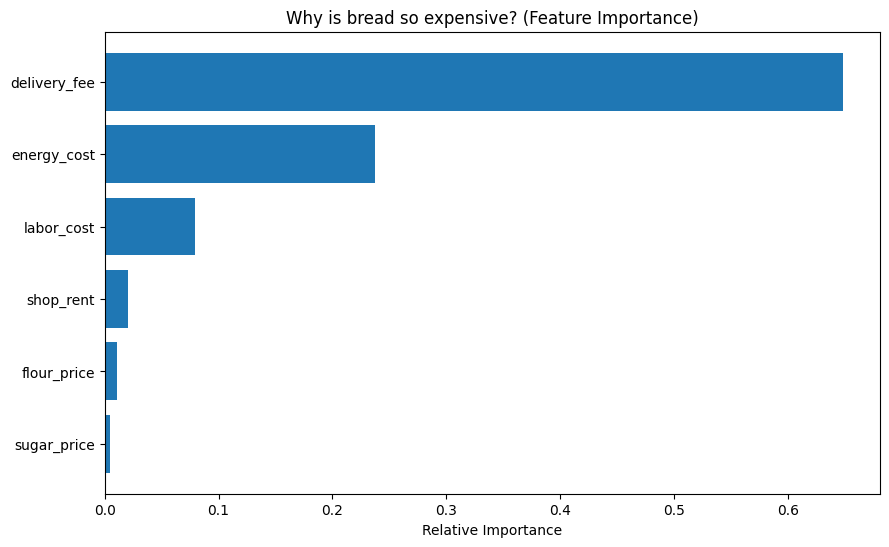

In [25]:
# 특성 중요도 추출
importances = rf.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('Why is bread so expensive? (Feature Importance)')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

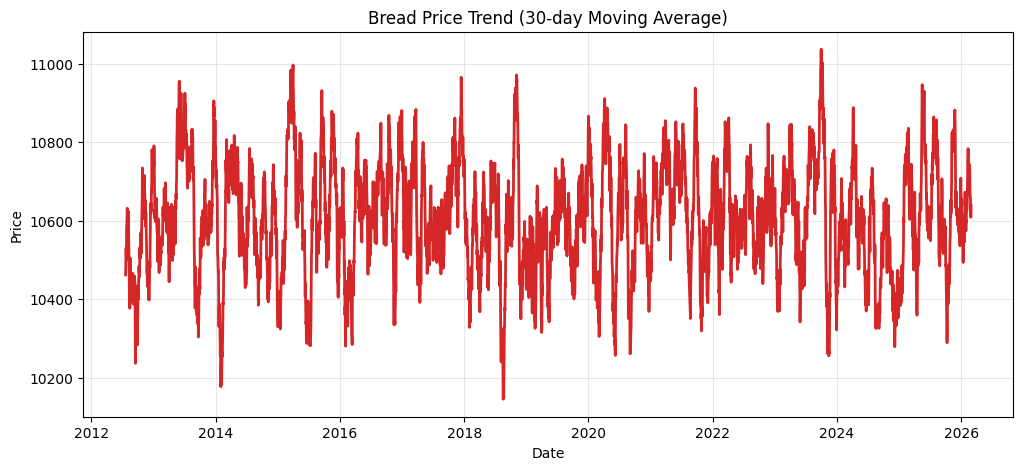

In [26]:
# 가상 날짜 데이터 생성 (최근 5,000일간의 기록)
df['date'] = pd.date_range(end='2026-02-27', periods=n_samples)
df_sorted = df.sort_values('date')

plt.figure(figsize=(12, 5))
plt.plot(df_sorted['date'], df_sorted['bread_price'].rolling(window=30).mean(), color='tab:red', lw=2)
plt.title('Bread Price Trend (30-day Moving Average)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True, alpha=0.3)
plt.show()

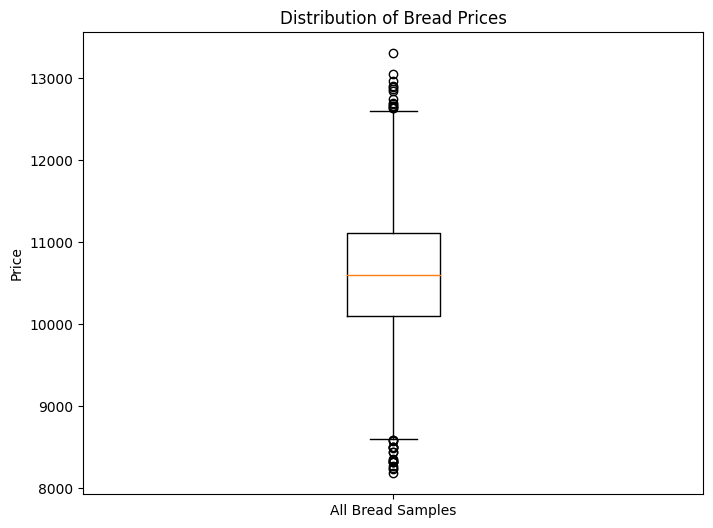

In [27]:
plt.figure(figsize=(8, 6))
plt.boxplot(df['bread_price'])
plt.title('Distribution of Bread Prices')
plt.ylabel('Price')
plt.xticks([1], ['All Bread Samples'])
plt.show()

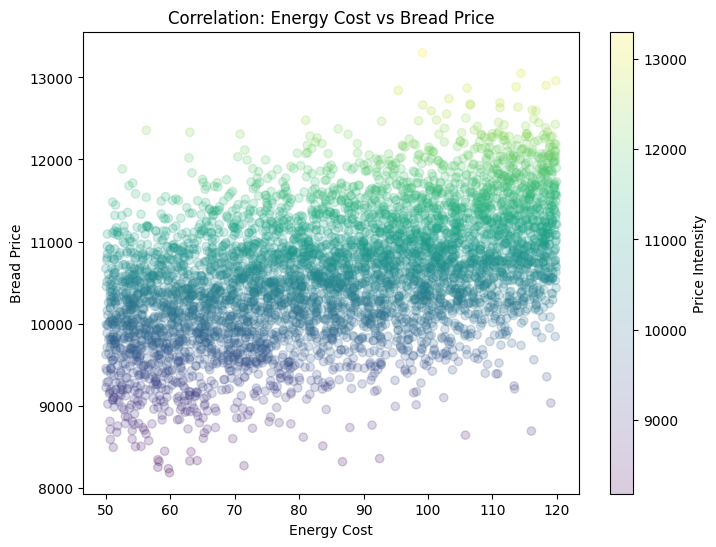

In [28]:
plt.figure(figsize=(8, 6))
plt.scatter(df['energy_cost'], df['bread_price'], alpha=0.2, c=df['bread_price'], cmap='viridis')
plt.title('Correlation: Energy Cost vs Bread Price')
plt.xlabel('Energy Cost')
plt.ylabel('Bread Price')
plt.colorbar(label='Price Intensity')
plt.show()

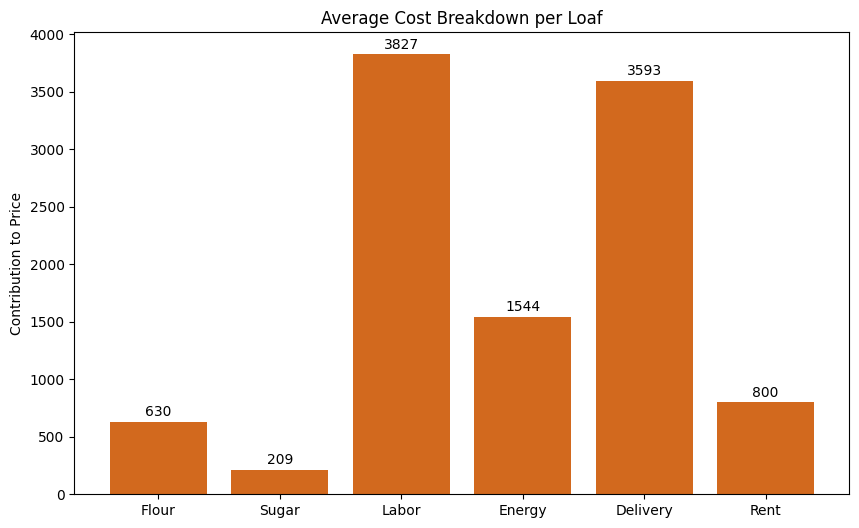

In [29]:
# 항목별 평균 기여도 (가중치 * 평균값)
contributions = {
    'Flour': df['flour_price'].mean() * 4.2,
    'Sugar': df['sugar_price'].mean() * 2.1,
    'Labor': df['labor_cost'].mean() * 0.35,
    'Energy': df['energy_cost'].mean() * 18.0,
    'Delivery': df['delivery_fee'].mean() * 1.2,
    'Rent': df['shop_rent'].mean() * 0.4
}

names = list(contributions.keys())
values = list(contributions.values())

plt.figure(figsize=(10, 6))
plt.bar(names, values, color='chocolate')
plt.title('Average Cost Breakdown per Loaf')
plt.ylabel('Contribution to Price')
for i, v in enumerate(values):
    plt.text(i, v + 50, f"{int(v)}", ha='center')
plt.show()

In [30]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 5,000개 데이터 생성 (이전 코드 참고)

# 1. 먼저 훈련+검증(80%)과 테스트(20%)로 나눔
train_input, test_input, train_target, test_target = train_test_split(
    X, y, test_size=0.2, random_state=42)

# 2. 훈련(80%)을 다시 훈련(80%)과 검증(20%)으로 나눔 (결과적으로 전체의 64%, 16%)
sub_input, val_input, sub_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42)

print(f"훈련용: {sub_input.shape}, 검증용: {val_input.shape}, 테스트용: {test_input.shape}")

훈련용: (3200, 6), 검증용: (800, 6), 테스트용: (1000, 6)


In [31]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

params = {
    'max_depth': randint(5, 30),
    'min_samples_split': randint(2, 20),
    'min_impurity_decrease': uniform(0.0001, 0.01)
}

# 결정 트리 회귀 모델로 랜덤 서치 수행
gs = RandomizedSearchCV(DecisionTreeRegressor(random_state=42), params,
                        n_iter=100, n_jobs=-1, random_state=42)
gs.fit(sub_input, sub_target)

print(f"최적의 매개변수: {gs.best_params_}")
dt = gs.best_estimator_
print(f"검증 세트 점수: {dt.score(val_input, val_target):.4f}")

최적의 매개변수: {'max_depth': 28, 'min_impurity_decrease': 0.008424426408004218, 'min_samples_split': 7}
검증 세트 점수: 0.9126


In [32]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_validate

# 1. 랜덤 포레스트 (OOB 점수 활용)
rf = RandomForestRegressor(oob_score=True, n_jobs=-1, random_state=42)
rf.fit(train_input, train_target)
print(f"랜덤 포레스트 OOB 점수: {rf.oob_score_:.4f}")

# 2. 그레이디언트 부스팅 (교차 검증 활용)
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(f"부스팅 교차 검증 점수: {np.mean(scores['test_score']):.4f}")

랜덤 포레스트 OOB 점수: 0.9733
부스팅 교차 검증 점수: 0.9889


최종 테스트 세트 정확도: 0.9723


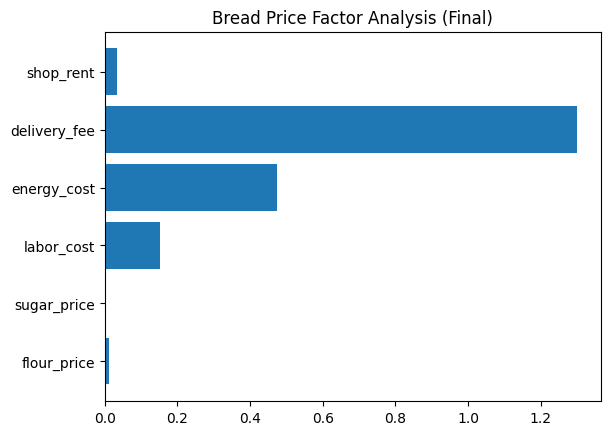

In [33]:
from sklearn.inspection import permutation_importance

# 최종 모델(예: rf)로 테스트 세트 평가 (딱 한 번 사용!)
final_score = rf.score(test_input, test_target)
print(f"최종 테스트 세트 정확도: {final_score:.4f}")

# 특성 중요도 확인 (어떤 원재료가 빵값을 올렸나?)
result = permutation_importance(rf, test_input, test_target, n_repeats=10, random_state=42)

plt.barh(X.columns, result.importances_mean)
plt.title("Bread Price Factor Analysis (Final)")
plt.show()

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# (데이터 생성 코드는 위와 동일하다고 가정)
# 특정 구간(3000번~4000번 데이터)에 '담합 프리미엄' 2,000원 추가
df.loc[3000:4000, 'bread_price'] += 2000
df['is_collusion'] = 0
df.loc[3000:4000, 'is_collusion'] = 1 # 나중에 검증용으로만 사용

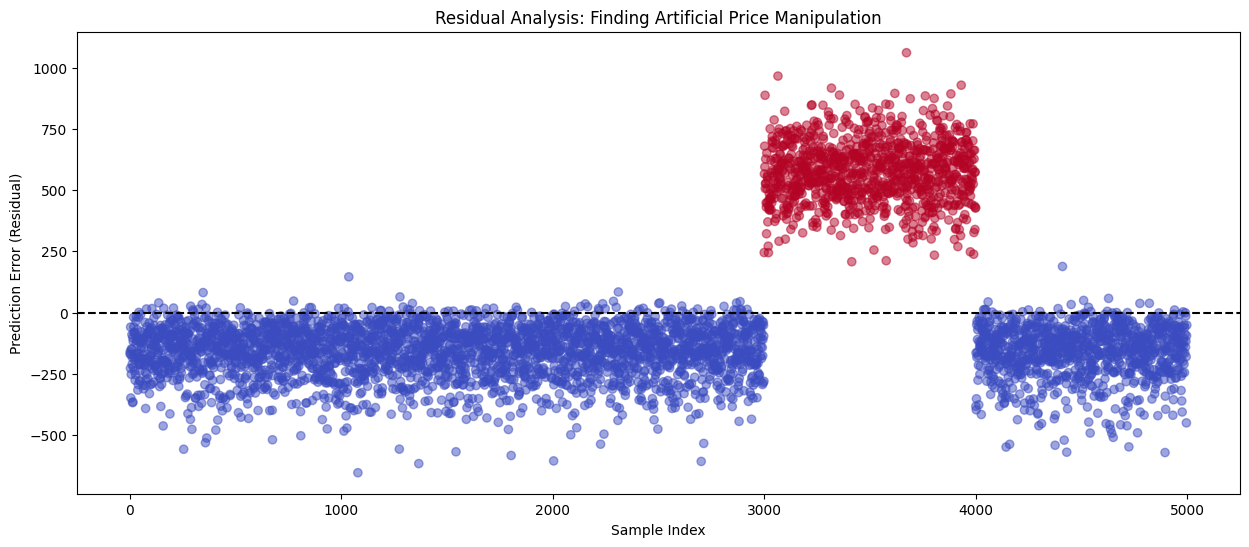

In [35]:
# 모델 훈련 (담합 여부 데이터는 넣지 않고 재료비만 넣음)
X = df[['flour_price', 'sugar_price', 'labor_cost', 'energy_cost', 'delivery_fee', 'shop_rent']]
y = df['bread_price']

rf = RandomForestRegressor(n_jobs=-1, random_state=42)
rf.fit(X, y)

# 잔차(실제값 - 예측값) 계산
df['residual'] = df['bread_price'] - rf.predict(X)

# 시각화: 인덱스에 따른 잔차 변화
plt.figure(figsize=(15, 6))
plt.scatter(df.index, df['residual'], c=df['is_collusion'], cmap='coolwarm', alpha=0.5)
plt.axhline(0, color='black', linestyle='--')
plt.title('Residual Analysis: Finding Artificial Price Manipulation')
plt.xlabel('Sample Index')
plt.ylabel('Prediction Error (Residual)')
plt.show()

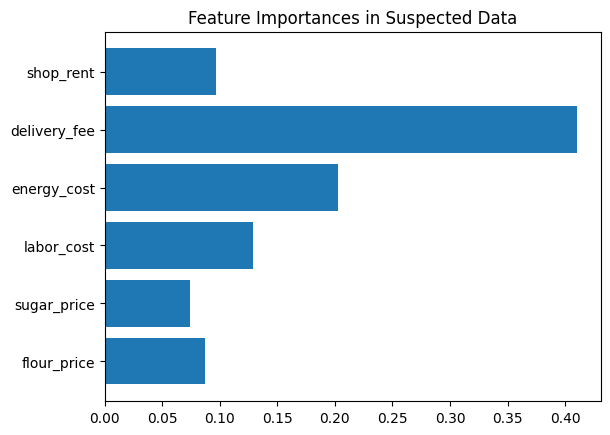

In [36]:
# 정상 데이터로만 만든 모델 vs 전체 데이터(담합 포함)로 만든 모델 비교
# (이 과정은 기업이 '이건 정당한 인상이다'라고 우길 때 반박용으로 쓰입니다)

importances = rf.feature_importances_
plt.barh(X.columns, importances)
plt.title('Feature Importances in Suspected Data')
plt.show()

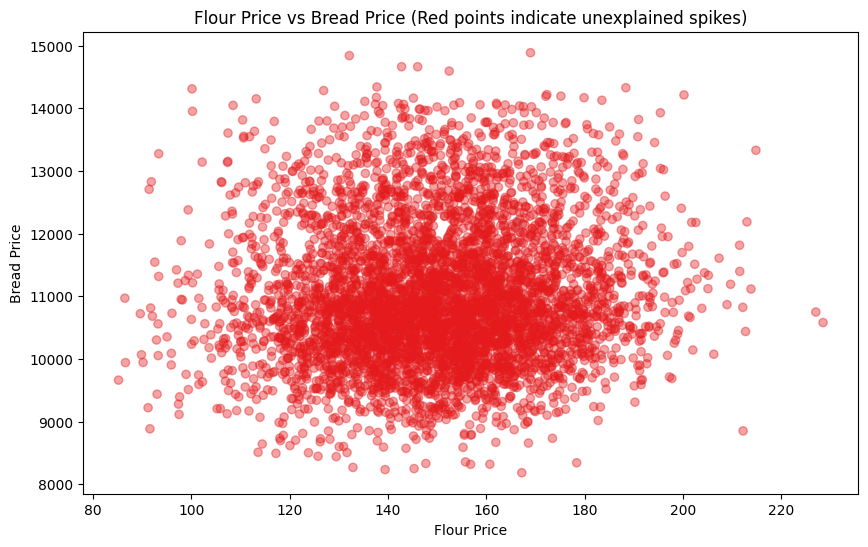

In [37]:
plt.figure(figsize=(10, 6))
plt.scatter(df['flour_price'], df['bread_price'], c=df['residual'] > 1000, cmap='Set1', alpha=0.4)
plt.title('Flour Price vs Bread Price (Red points indicate unexplained spikes)')
plt.xlabel('Flour Price')
plt.ylabel('Bread Price')
plt.show()